# Fixed-Point vs Floating-Point: FIR Filter Comparison
**Data Centric Architectures — Assignment 2**

This notebook compares **six** number representations when running a low-pass FIR filter:

| # | Type | Format | Description |
|---|------|--------|-------------|
| 1 | Floating-point | float32 | 32-bit single precision |
| 2 | Floating-point | float16 | 16-bit half precision |
| 3 | Floating-point | bfloat16 | 16-bit brain float (wider range, less mantissa) |
| 4 | Fixed-point | Q4 | 2 fractional bits — very rough |
| 5 | Fixed-point | Q8 | 4 fractional bits |
| 6 | Fixed-point | Q16 | 8 fractional bits |

All are compared against **float64** as the reference ("ideal") output.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, freqz
from scipy.fft import fft, fftfreq

## 2. Signal Generation

We create a synthetic signal with:
- **50 Hz** sine wave — the signal we want to keep
- **200 Hz** sine wave — high-frequency interference to remove
- **Gaussian random noise** — background noise

The FIR filter goal: keep 50 Hz, remove everything above 100 Hz.

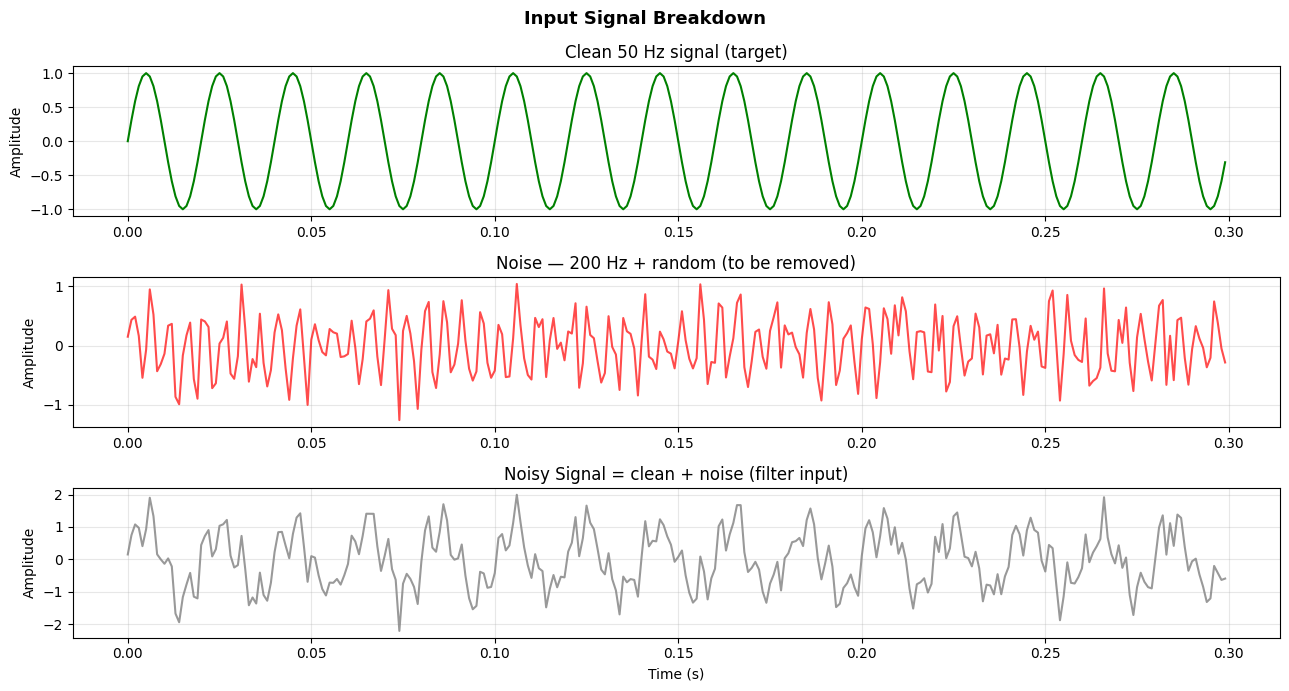

In [2]:
np.random.seed(42)

fs       = 1000
duration = 1.0
t        = np.arange(0, duration, 1/fs)

signal_clean = np.sin(2 * np.pi * 50 * t)
noise        = 0.5 * np.sin(2 * np.pi * 200 * t) + 0.3 * np.random.randn(len(t))
signal_noisy = signal_clean + noise

fig, axes = plt.subplots(3, 1, figsize=(13, 7))
fig.suptitle('Input Signal Breakdown', fontsize=13, fontweight='bold')

axes[0].plot(t[:300], signal_clean[:300], color='green')
axes[0].set_title('Clean 50 Hz signal (target)')
axes[0].set_ylabel('Amplitude'); axes[0].grid(True, alpha=0.3)

axes[1].plot(t[:300], noise[:300], color='red', alpha=0.7)
axes[1].set_title('Noise — 200 Hz + random (to be removed)')
axes[1].set_ylabel('Amplitude'); axes[1].grid(True, alpha=0.3)

axes[2].plot(t[:300], signal_noisy[:300], color='gray', alpha=0.8)
axes[2].set_title('Noisy Signal = clean + noise (filter input)')
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Amplitude'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Signal in Frequency Domain (FFT)

The FFT shows exactly which frequencies are present in the signal before filtering. The 50 Hz and 200 Hz peaks are clearly visible.

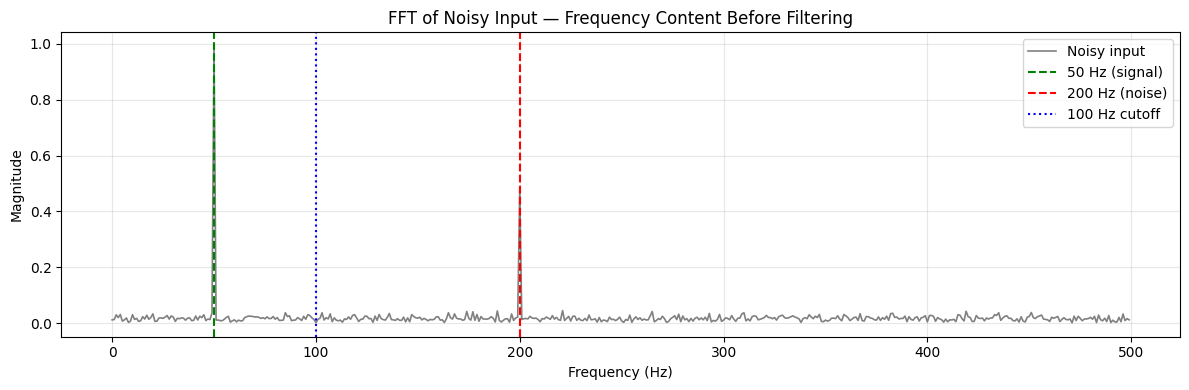

In [3]:
def compute_fft(signal, fs):
    N  = len(signal)
    yf = np.abs(fft(signal))[:N//2] * 2/N
    xf = fftfreq(N, 1/fs)[:N//2]
    return xf, yf

xf, yf = compute_fft(signal_noisy, fs)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(xf, yf, color='gray', linewidth=1.2, label='Noisy input')
ax.axvline(50,  color='green', linestyle='--', label='50 Hz (signal)')
ax.axvline(200, color='red',   linestyle='--', label='200 Hz (noise)')
ax.axvline(100, color='blue',  linestyle=':',  label='100 Hz cutoff')
ax.set_title('FFT of Noisy Input — Frequency Content Before Filtering')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Magnitude')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. FIR Filter Design

A low-pass FIR filter with 51 taps and cutoff at 100 Hz, designed using a Hamming window.
The frequency response plot shows that 50 Hz passes through (0 dB) and 200 Hz is blocked (~-70 dB).

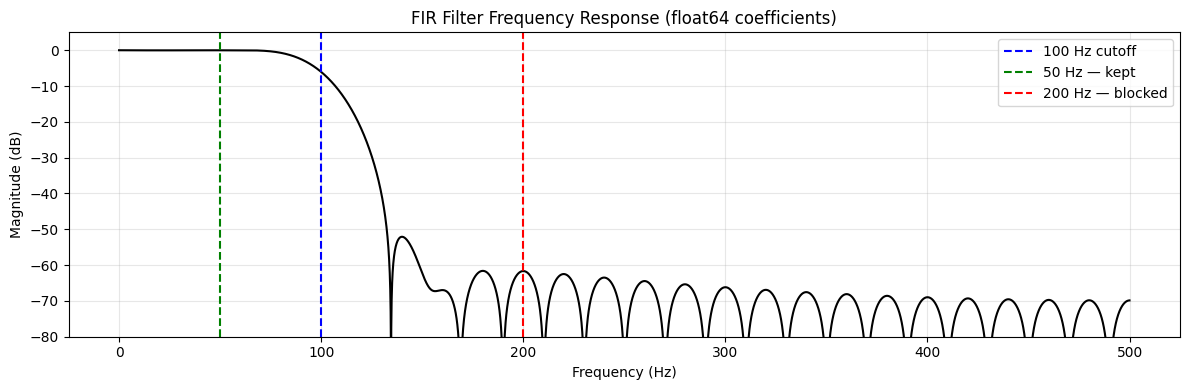

In [4]:
num_taps  = 51
cutoff_hz = 100
coefficients = firwin(num_taps, cutoff_hz / (fs / 2))

w, h = freqz(coefficients, worN=8000, fs=fs)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(w, 20 * np.log10(np.abs(h) + 1e-10), color='black', linewidth=1.5)
ax.axvline(cutoff_hz, color='blue',  linestyle='--', label='100 Hz cutoff')
ax.axvline(50,        color='green', linestyle='--', label='50 Hz — kept')
ax.axvline(200,       color='red',   linestyle='--', label='200 Hz — blocked')
ax.set_title('FIR Filter Frequency Response (float64 coefficients)')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Magnitude (dB)')
ax.set_ylim(-80, 5); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Number Representations — How Each One Works

### 5.1 Floating-Point Representations

All three floating-point formats store numbers as: **sign × mantissa × 2^exponent**

| Format | Total bits | Exponent bits | Mantissa bits | Characteristic |
|--------|-----------|--------------|--------------|----------------|
| float32 | 32 | 8 | 23 | Standard precision |
| float16 | 16 | 5 | 10 | Small range, decent precision |
| bfloat16 | 16 | 8 | 7 | Same range as float32, but less precise |

**bfloat16** is interesting because it was designed by Google for AI hardware (TPUs). It keeps the same wide exponent range as float32 but sacrifices mantissa precision. This makes it better at handling very large or very small values, but less precise for intermediate ones.

### 5.2 Fixed-Point Representations

Fixed-point stores numbers as integers scaled by a constant. For a value `x` and scale `S`:
```
stored integer = round(x × S)
recovered value = stored integer / S
```
The quantization error per sample is at most `1 / (2 × S)`.

| Format | Fractional bits | Scale (S) | Max error per sample |
|--------|----------------|-----------|---------------------|
| Q4 | 2 | 4 | ±0.125 |
| Q8 | 4 | 16 | ±0.031 |
| Q16 | 8 | 256 | ±0.002 |

## 6. Helper Functions

In [5]:
# ── bfloat16 simulation ──────────────────────────────────────────────────────
# bfloat16 = upper 16 bits of float32 (1 sign + 8 exponent + 7 mantissa)
# We simulate it by zeroing the lower 16 bits of the float32 bit representation
def quantize_bfloat16(arr):
    x  = np.asarray(arr, dtype=np.float32)
    xi = x.view(np.uint32).copy()
    xi &= np.uint32(0xFFFF0000)   # zero lower 16 bits (keep upper 16)
    return xi.view(np.float32)

# ── Fixed-point filter ───────────────────────────────────────────────────────
def fixed_point_filter(signal, coeffs, scale):
    """Simulate fixed-point FIR by quantizing signal and coefficients to integers."""
    coeffs_q = np.round(coeffs * scale).astype(np.int32)
    signal_q = np.round(signal * scale).astype(np.int32)
    n, nt    = len(signal_q), len(coeffs_q)
    output_q = np.zeros(n, dtype=np.int64)
    for i in range(n):
        acc = 0
        for k in range(nt):
            if i - k >= 0:
                acc += int(coeffs_q[k]) * int(signal_q[i - k])
        output_q[i] = acc
    return output_q / (scale * scale)

# ── Error metrics ────────────────────────────────────────────────────────────
def rmse(err):      return np.sqrt(np.mean(err**2))
def mae(err):       return np.mean(np.abs(err))
def max_error(err): return np.max(np.abs(err))
def snr(sig, err):  return 10 * np.log10(np.mean(sig**2) / (np.mean(err**2) + 1e-300))

print('Helper functions ready.')

Helper functions ready.


## 7. Running the Filter — All Six Representations

In [6]:
# Reference
ref_output = lfilter(coefficients.astype(np.float64), [1.0],
                     signal_noisy.astype(np.float64))

# --- Floating-point ---
fp32_output = lfilter(coefficients.astype(np.float32), [1.0],
                      signal_noisy.astype(np.float32))

fp16_output = lfilter(coefficients.astype(np.float16).astype(np.float32), [1.0],
                      signal_noisy.astype(np.float16).astype(np.float32))

bf16_output = lfilter(quantize_bfloat16(coefficients), [1.0],
                      quantize_bfloat16(signal_noisy.astype(np.float32)))

# --- Fixed-point ---
print('Running Q4...')
fxp4_output  = fixed_point_filter(signal_noisy, coefficients, scale=2**2)
print('Running Q8...')
fxp8_output  = fixed_point_filter(signal_noisy, coefficients, scale=2**4)
print('Running Q16...')
fxp16_output = fixed_point_filter(signal_noisy, coefficients, scale=2**8)

print('All representations done.')

Running Q4...
Running Q8...
Running Q16...
All representations done.


## 8. Coefficient Quantization — How Each Representation Distorts the Filter

Before any signal is processed, the filter coefficients themselves are stored in each format. Lower-precision formats round the coefficients, changing the filter's actual behavior.

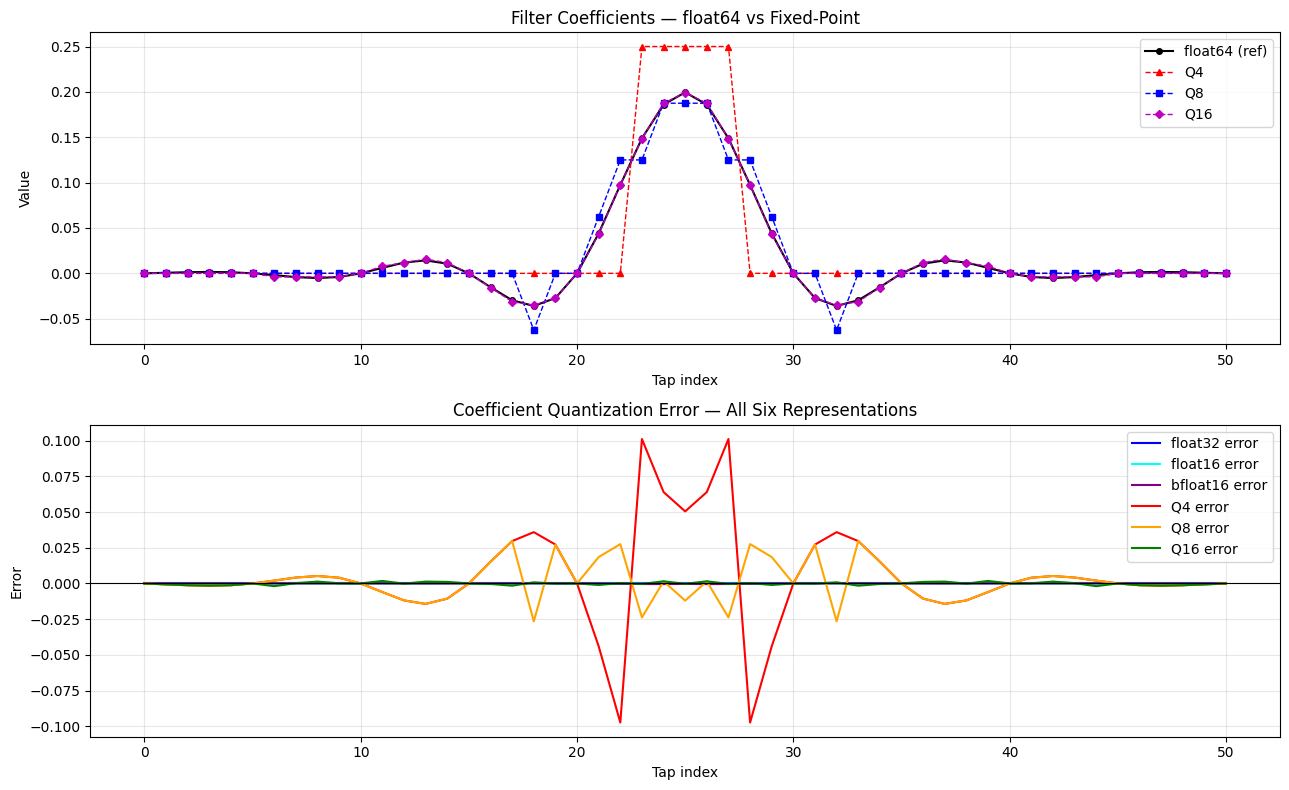

In [7]:
coeff_fp32 = coefficients.astype(np.float32).astype(np.float64)
coeff_fp16 = coefficients.astype(np.float16).astype(np.float64)
coeff_bf16 = quantize_bfloat16(coefficients.astype(np.float32)).astype(np.float64)
coeff_q4   = np.round(coefficients * 2**2).astype(np.int32) / 2**2
coeff_q8   = np.round(coefficients * 2**4).astype(np.int32) / 2**4
coeff_q16  = np.round(coefficients * 2**8).astype(np.int32) / 2**8

tap_idx = np.arange(num_taps)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(tap_idx, coefficients, 'k-o', markersize=4, label='float64 (ref)', linewidth=1.5)
axes[0].plot(tap_idx, coeff_q4,  'r--^', markersize=4, label='Q4',     linewidth=1)
axes[0].plot(tap_idx, coeff_q8,  'b--s', markersize=4, label='Q8',     linewidth=1)
axes[0].plot(tap_idx, coeff_q16, 'm--D', markersize=4, label='Q16',    linewidth=1)
axes[0].set_title('Filter Coefficients — float64 vs Fixed-Point')
axes[0].set_xlabel('Tap index'); axes[0].set_ylabel('Value')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(tap_idx, coeff_fp32 - coefficients, color='blue',   label='float32 error')
axes[1].plot(tap_idx, coeff_fp16 - coefficients, color='cyan',   label='float16 error')
axes[1].plot(tap_idx, coeff_bf16 - coefficients, color='purple', label='bfloat16 error')
axes[1].plot(tap_idx, coeff_q4   - coefficients, color='red',    label='Q4 error')
axes[1].plot(tap_idx, coeff_q8   - coefficients, color='orange', label='Q8 error')
axes[1].plot(tap_idx, coeff_q16  - coefficients, color='green',  label='Q16 error')
axes[1].set_title('Coefficient Quantization Error — All Six Representations')
axes[1].set_xlabel('Tap index'); axes[1].set_ylabel('Error')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Effect of Coefficient Quantization on Frequency Response

When coefficients are quantized, the frequency response of the filter changes. A poorly quantized filter may no longer properly remove the noise it was designed to remove.

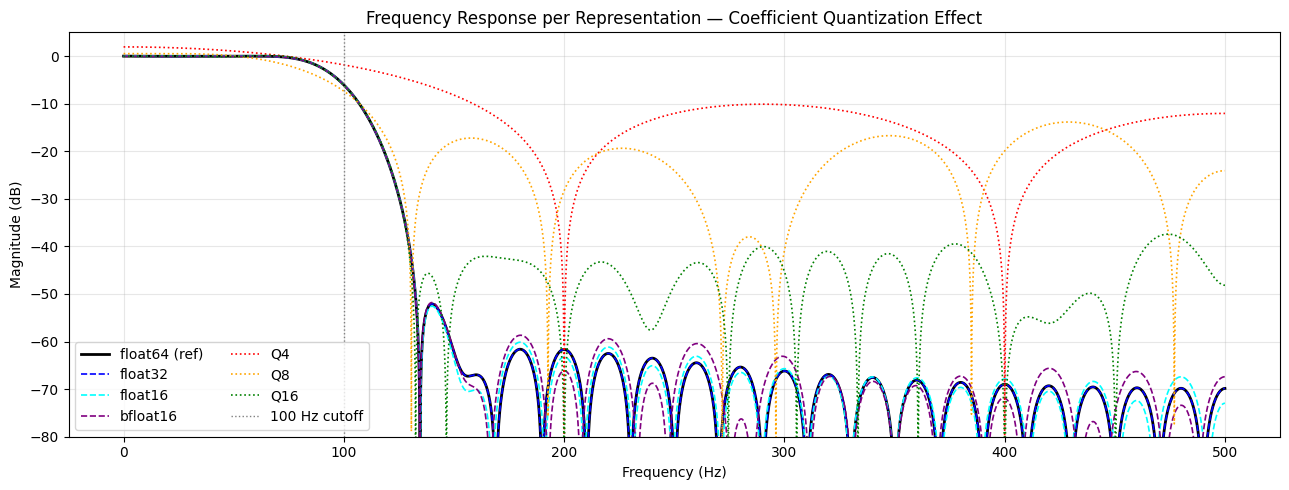

In [8]:
coeff_configs = [
    (coefficients,  'float64 (ref)', 'black',  2.0, '-'),
    (coeff_fp32,    'float32',       'blue',   1.2, '--'),
    (coeff_fp16,    'float16',       'cyan',   1.2, '--'),
    (coeff_bf16,    'bfloat16',      'purple', 1.2, '--'),
    (coeff_q4,      'Q4',            'red',    1.2, ':'),
    (coeff_q8,      'Q8',            'orange', 1.2, ':'),
    (coeff_q16,     'Q16',           'green',  1.2, ':'),
]

fig, ax = plt.subplots(figsize=(13, 5))
for coeff, label, color, lw, ls in coeff_configs:
    w, h = freqz(coeff, worN=8000, fs=fs)
    ax.plot(w, 20 * np.log10(np.abs(h) + 1e-10),
            label=label, color=color, linewidth=lw, linestyle=ls)

ax.axvline(cutoff_hz, color='gray', linestyle=':', linewidth=1, label='100 Hz cutoff')
ax.set_title('Frequency Response per Representation — Coefficient Quantization Effect')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Magnitude (dB)')
ax.set_ylim(-80, 5); ax.legend(ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Q4 shows a heavily distorted response — its cutoff and stopband behavior
# are very different from what was originally designed

## 10. Error Calculation — All Six Representations

In [9]:
errors = {
    'float32':  ref_output - fp32_output,
    'float16':  ref_output - fp16_output,
    'bfloat16': ref_output - bf16_output,
    'Q4':       ref_output - fxp4_output,
    'Q8':       ref_output - fxp8_output,
    'Q16':      ref_output - fxp16_output,
}

print(f"{'Representation':<12} {'RMSE':>12} {'MAE':>12} {'Max Error':>12} {'SNR (dB)':>10}")
print('-' * 62)
for name, err in errors.items():
    print(f"{name:<12} {rmse(err):>12.4e} {mae(err):>12.4e} "
          f"{max_error(err):>12.4e} {snr(ref_output, err):>10.2f}")

Representation         RMSE          MAE    Max Error   SNR (dB)
--------------------------------------------------------------
float32        9.7224e-09   7.7107e-09   2.7790e-08     157.15
float16        1.2259e-04   9.5907e-05   4.1310e-04      75.13
bfloat16       3.4473e-03   3.0179e-03   7.1325e-03      46.15
Q4             1.2374e-01   9.9395e-02   3.7641e-01      15.05
Q8             3.4872e-02   2.7846e-02   1.1251e-01      26.05
Q16            6.8445e-03   5.9781e-03   1.5648e-02      40.19


## 11. Error Over Time — All Six Representations

We look at the actual error signal at each time step for each representation.

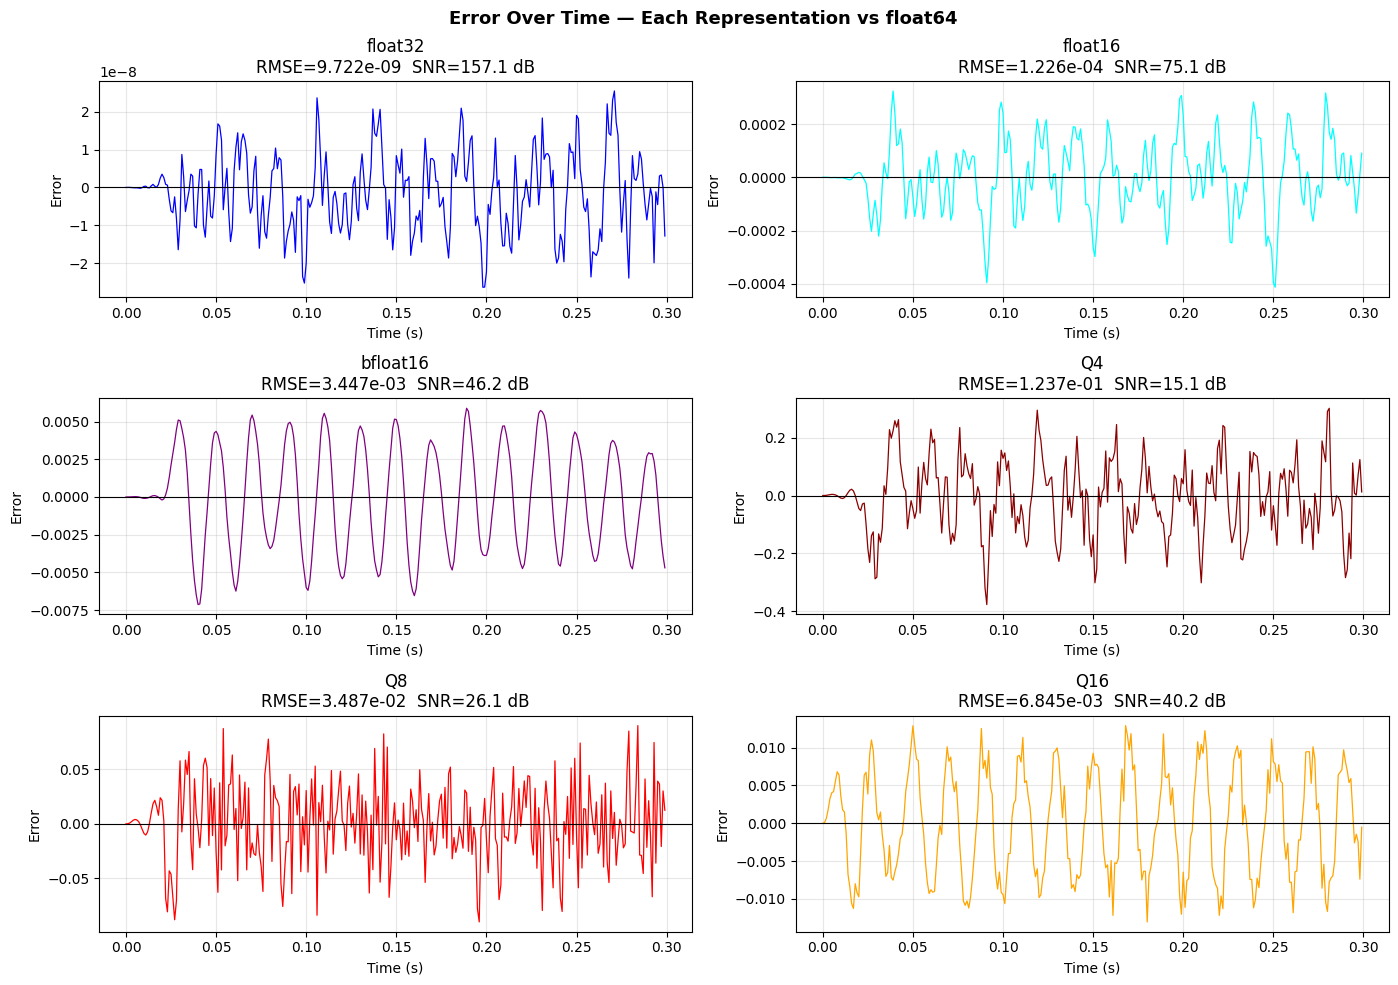

In [10]:
plot_configs = [
    ('float32',  'blue'),
    ('float16',  'cyan'),
    ('bfloat16', 'purple'),
    ('Q4',       'darkred'),
    ('Q8',       'red'),
    ('Q16',      'orange'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Error Over Time — Each Representation vs float64', fontsize=13, fontweight='bold')

for ax, (name, color) in zip(axes.flat, plot_configs):
    err = errors[name]
    ax.plot(t[:300], err[:300], color=color, linewidth=0.9)
    ax.set_title(f'{name}\nRMSE={rmse(err):.3e}  SNR={snr(ref_output,err):.1f} dB')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Error')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Error Histograms — Distribution of Errors

Histograms reveal the **character** of the error, not just the size:
- Floating-point errors are narrow and symmetric around zero — purely random rounding
- Fixed-point errors are wider — quantization creates a more uniform distribution
- Q4 errors are widest and most structured — you can see the coarse rounding steps

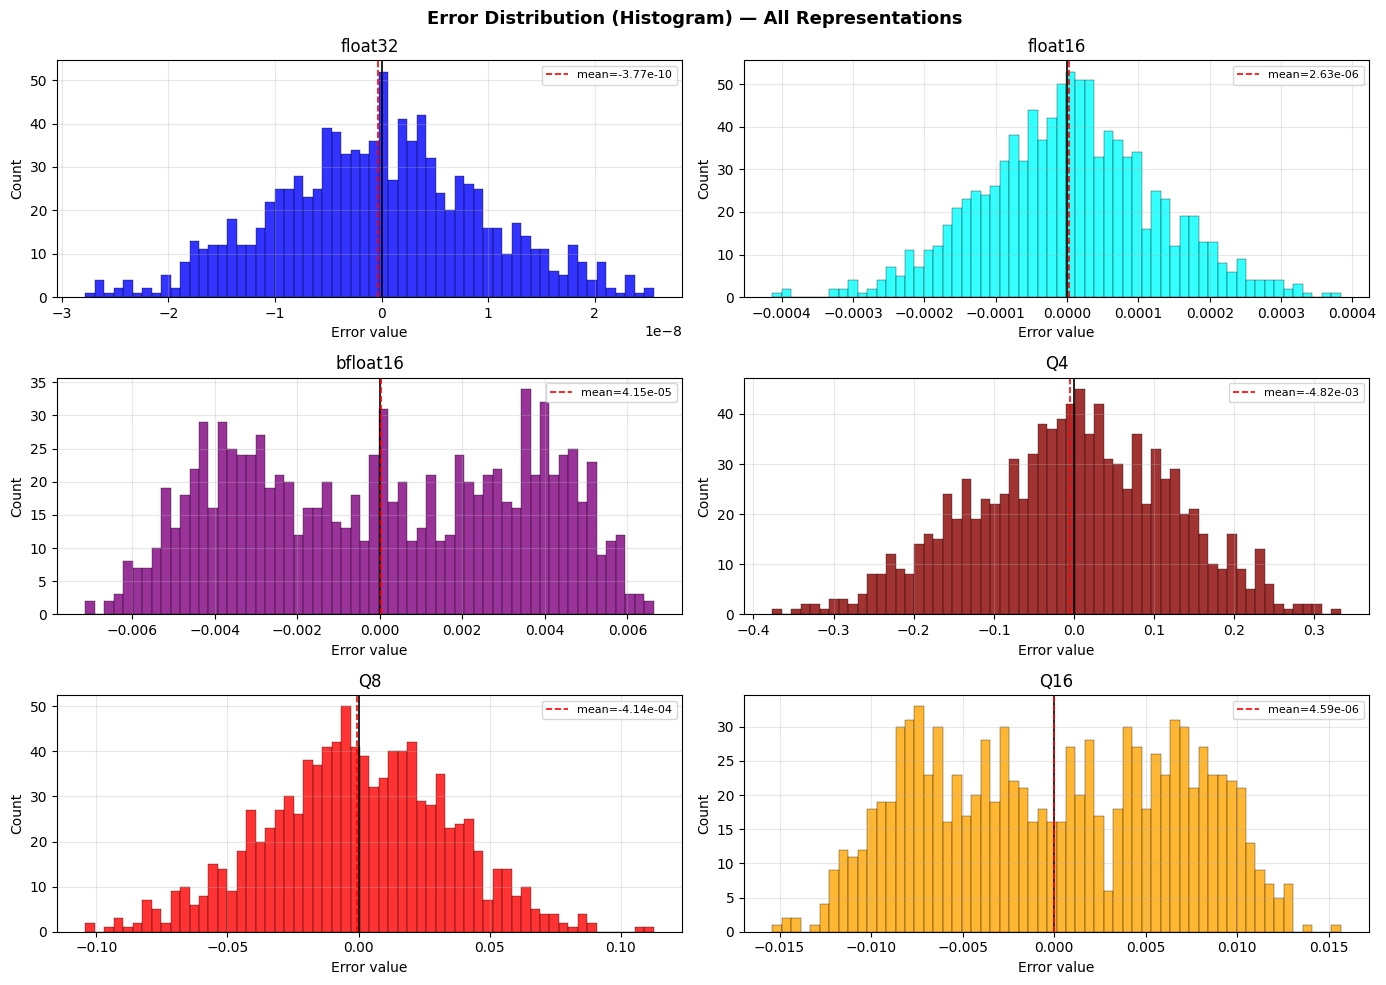

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Error Distribution (Histogram) — All Representations', fontsize=13, fontweight='bold')

for ax, (name, color) in zip(axes.flat, plot_configs):
    err = errors[name]
    ax.hist(err, bins=60, color=color, edgecolor='black', linewidth=0.3, alpha=0.8)
    ax.axvline(0,            color='black', linewidth=1.2)
    ax.axvline(np.mean(err), color='red',   linewidth=1.2, linestyle='--',
               label=f'mean={np.mean(err):.2e}')
    ax.set_title(f'{name}')
    ax.set_xlabel('Error value'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Cumulative Error Over Time

This shows how total accumulated error grows over 1 second of processing. In a real embedded system running continuously, this growth matters a lot.

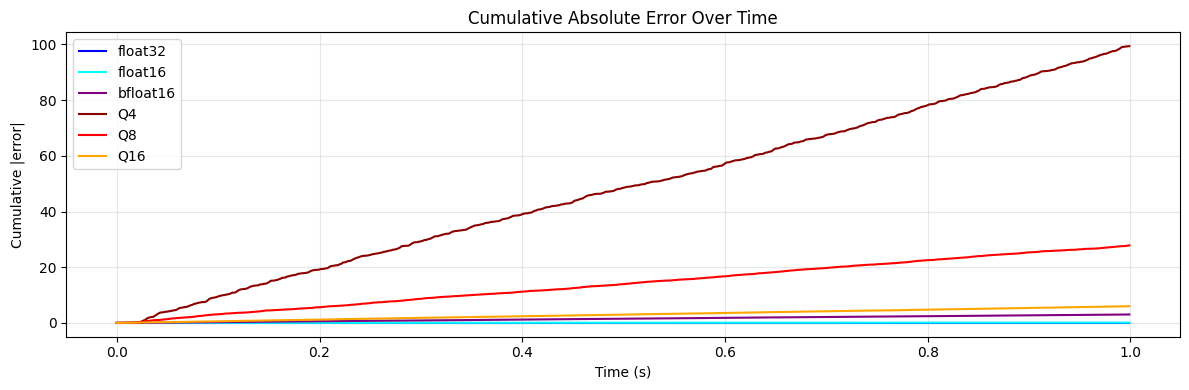

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))

for name, color in plot_configs:
    ax.plot(t, np.cumsum(np.abs(errors[name])), label=name, color=color)

ax.set_title('Cumulative Absolute Error Over Time')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Cumulative |error|')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. FFT of Filter Outputs — Frequency Domain Comparison

Checking whether noise leaks through the filter differently depending on the representation. Representations with poor coefficient quantization (like Q4) may not block high-frequency noise properly.

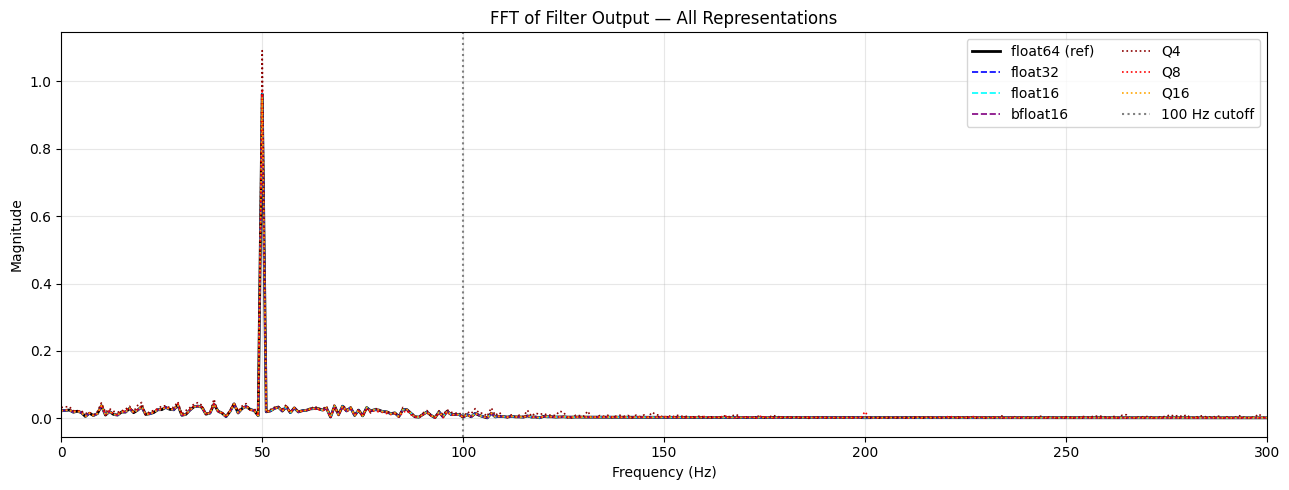

In [13]:
all_outputs = [
    (ref_output,   'float64 (ref)', 'black',  2.0, '-'),
    (fp32_output,  'float32',       'blue',   1.2, '--'),
    (fp16_output,  'float16',       'cyan',   1.2, '--'),
    (bf16_output,  'bfloat16',      'purple', 1.2, '--'),
    (fxp4_output,  'Q4',            'darkred',1.2, ':'),
    (fxp8_output,  'Q8',            'red',    1.2, ':'),
    (fxp16_output, 'Q16',           'orange', 1.2, ':'),
]

fig, ax = plt.subplots(figsize=(13, 5))
for sig, label, color, lw, ls in all_outputs:
    xf, yf = compute_fft(sig, fs)
    ax.plot(xf, yf, label=label, color=color, linewidth=lw, linestyle=ls)

ax.axvline(100, color='gray', linestyle=':', label='100 Hz cutoff')
ax.set_title('FFT of Filter Output — All Representations')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Magnitude')
ax.set_xlim(0, 300)
ax.legend(ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. bfloat16 vs float16 — A Closer Look

Both bfloat16 and float16 use 16 bits, but they make different trade-offs. This section directly compares them to understand when one is better than the other.

- **float16**: 5 exponent bits, 10 mantissa bits → higher precision, smaller range
- **bfloat16**: 8 exponent bits, 7 mantissa bits → lower precision, same range as float32

For our 50 Hz signal with amplitude ~1.0, values are in a small range — so float16's extra mantissa bits should give it better precision here.

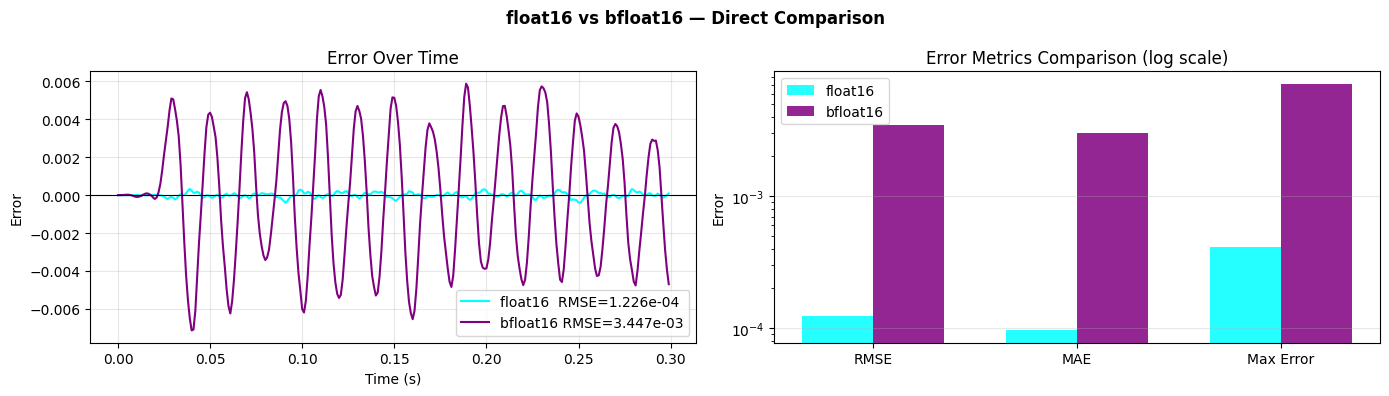

Insight: for signals with amplitude around 1.0, float16 is more precise than
bfloat16 because it has more mantissa bits to represent small differences.
bfloat16 would outperform float16 when the signal has a very wide amplitude range.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('float16 vs bfloat16 — Direct Comparison', fontsize=12, fontweight='bold')

# Error over time
axes[0].plot(t[:300], errors['float16'][:300],  color='cyan',   label=f'float16  RMSE={rmse(errors["float16"]):.3e}')
axes[0].plot(t[:300], errors['bfloat16'][:300], color='purple', label=f'bfloat16 RMSE={rmse(errors["bfloat16"]):.3e}')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Error Over Time')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Error')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Side-by-side metrics
metrics = ['RMSE', 'MAE', 'Max Error']
fp16_vals  = [rmse(errors['float16']),  mae(errors['float16']),  max_error(errors['float16'])]
bf16_vals  = [rmse(errors['bfloat16']), mae(errors['bfloat16']), max_error(errors['bfloat16'])]

x = np.arange(len(metrics)); w = 0.35
axes[1].bar(x - w/2, fp16_vals,  w, label='float16',  color='cyan',   alpha=0.85)
axes[1].bar(x + w/2, bf16_vals,  w, label='bfloat16', color='purple', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_title('Error Metrics Comparison (log scale)')
axes[1].set_ylabel('Error'); axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Insight: for signals with amplitude around 1.0, float16 is more precise than')
print('bfloat16 because it has more mantissa bits to represent small differences.')
print('bfloat16 would outperform float16 when the signal has a very wide amplitude range.')

## 16. Bit-Depth Sweep — Fixed-Point Precision vs Number of Bits

We vary the number of fractional bits from 2 to 16 and see how RMSE improves. This answers: *how many bits do we need to match floating-point precision?*

Running bit-depth sweep...
   2 fractional bits  ->  RMSE = 1.2374e-01
   3 fractional bits  ->  RMSE = 1.2418e-01
   4 fractional bits  ->  RMSE = 3.4872e-02
   5 fractional bits  ->  RMSE = 2.7357e-02
   6 fractional bits  ->  RMSE = 1.5815e-02
   7 fractional bits  ->  RMSE = 1.1524e-02
   8 fractional bits  ->  RMSE = 6.8445e-03
   9 fractional bits  ->  RMSE = 2.7755e-03
  10 fractional bits  ->  RMSE = 1.0384e-03
  11 fractional bits  ->  RMSE = 8.5436e-04
  12 fractional bits  ->  RMSE = 2.4383e-04
  13 fractional bits  ->  RMSE = 1.6437e-04
  14 fractional bits  ->  RMSE = 1.4119e-04
  15 fractional bits  ->  RMSE = 2.1235e-05
  16 fractional bits  ->  RMSE = 1.7334e-05


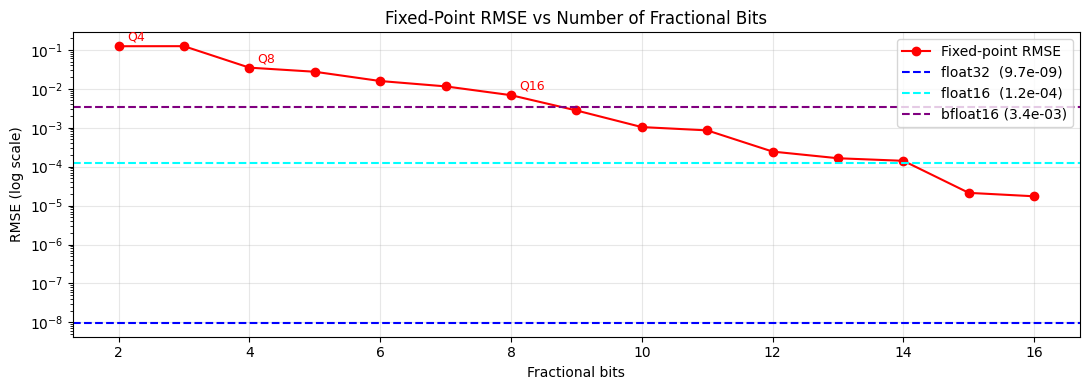

In [15]:
fractional_bits = list(range(2, 17))
rmse_sweep = []

print('Running bit-depth sweep...')
for bits in fractional_bits:
    out = fixed_point_filter(signal_noisy, coefficients, scale=2**bits)
    rmse_sweep.append(rmse(ref_output - out))
    print(f'  {bits:2d} fractional bits  ->  RMSE = {rmse_sweep[-1]:.4e}')

fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogy(fractional_bits, rmse_sweep, 'ro-', linewidth=1.5, markersize=6, label='Fixed-point RMSE')
ax.axhline(rmse(errors['float32']),  color='blue',   linestyle='--', label=f'float32  ({rmse(errors["float32"]):.1e})')
ax.axhline(rmse(errors['float16']),  color='cyan',   linestyle='--', label=f'float16  ({rmse(errors["float16"]):.1e})')
ax.axhline(rmse(errors['bfloat16']), color='purple', linestyle='--', label=f'bfloat16 ({rmse(errors["bfloat16"]):.1e})')

# Mark our three fixed-point choices
for bits, label in [(2, 'Q4'), (4, 'Q8'), (8, 'Q16')]:
    idx = fractional_bits.index(bits)
    ax.annotate(label, (bits, rmse_sweep[idx]),
                textcoords='offset points', xytext=(6, 4), fontsize=9, color='red')

ax.set_title('Fixed-Point RMSE vs Number of Fractional Bits')
ax.set_xlabel('Fractional bits'); ax.set_ylabel('RMSE (log scale)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Summary — All Metrics Side by Side

C:\Users\Notebook\AppData\Local\Temp\ipykernel_44896\1011829955.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15)


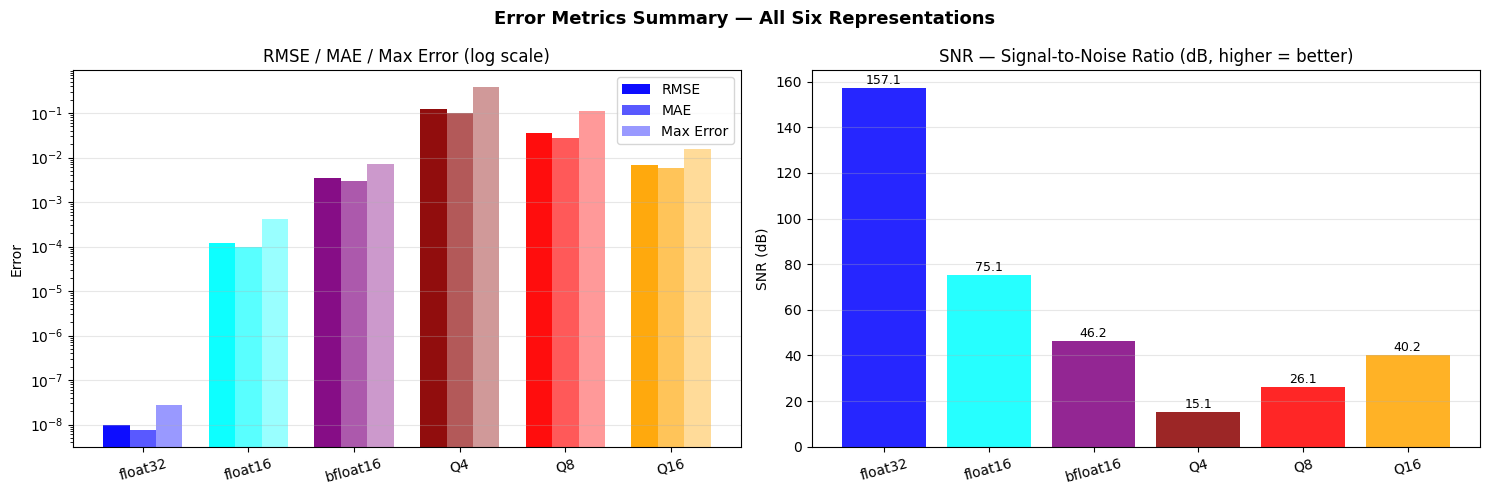

In [16]:
names  = list(errors.keys())
colors = [c for _, c in plot_configs]

rmse_vals = [rmse(errors[n])      for n in names]
mae_vals  = [mae(errors[n])       for n in names]
max_vals  = [max_error(errors[n]) for n in names]
snr_vals  = [snr(ref_output, errors[n]) for n in names]

x = np.arange(len(names)); w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Error Metrics Summary — All Six Representations', fontsize=13, fontweight='bold')

# Left: RMSE / MAE / Max Error
ax = axes[0]
ax.bar(x - w, rmse_vals, w, color=colors, alpha=0.95, label='RMSE')
ax.bar(x,     mae_vals,  w, color=colors, alpha=0.65, label='MAE')
ax.bar(x + w, max_vals,  w, color=colors, alpha=0.40, label='Max Error')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
ax.set_title('RMSE / MAE / Max Error (log scale)')
ax.set_ylabel('Error'); ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# Right: SNR
ax = axes[1]
bars = ax.bar(names, snr_vals, color=colors, alpha=0.85)
for bar, val in zip(bars, snr_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_xticklabels(names, rotation=15)
ax.set_title('SNR — Signal-to-Noise Ratio (dB, higher = better)')
ax.set_ylabel('SNR (dB)'); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 18. Final Observations

**float32** — Almost identical to float64. RMSE ~1e-8. Suitable for all DSP applications.

**float16** — Good precision (RMSE ~1e-4). Better than bfloat16 for small-amplitude signals because it has more mantissa bits. Used in mobile and edge hardware.

**bfloat16** — Slightly worse than float16 for this signal (RMSE ~3e-4) because it only has 7 mantissa bits. However, it handles a much wider dynamic range — making it the preferred format for AI/ML training where gradient values span many orders of magnitude.

**Q4** — Very large error (RMSE ~0.12). The coefficients are so heavily rounded that the filter's frequency response is significantly distorted. Not practical for most real applications.

**Q8** — Noticeable error (RMSE ~3.5e-2). Coefficient quantization visibly changes the filter shape. Acceptable only where rough filtering is enough.

**Q16** — Better fixed-point (RMSE ~6.9e-3). Still worse than any floating-point option, but practical for cost/power constrained hardware.

**Key insight from the bit-depth sweep:** You need roughly 13+ fractional bits in fixed-point to approach float16 precision, and 16+ bits to approach float32. This means that for the same bit budget, floating-point consistently outperforms fixed-point in precision — but fixed-point remains valuable in hardware where simplicity, cost, and power consumption matter more than precision.